Author:  
Manuel Eugenio Morocho Cayamcela, PhD

# **Test**  
## Outlier Handling and Group Operations for E-commerce Transactions

### **Objective and Scope of the Work:**

The goal of this work is to apply data mining techniques to identify the most relevant products in our dataset. In addition, the interquartile range (IQR) method will be used to detect and remove outliers, thereby improving the quality of our data and the accuracy of our analyses.

This work will cover the following aspects:

1. Data loading and initial exploration.
2. Exploratory data analysis to understand the characteristics and distributions of the variables.
3. Application of the IQR method for outlier detection and removal.
4. Application of data mining techniques to identify the most relevant products.
5. Interpretation and visualization of the results.

### **Phase I:** Data Loading and Preprocessing

#### Importing the necessary libraries

In [1]:
#%pip install numpy pandas matplotlib seaborn

# Import the 'numpy' library as 'np'
import numpy as np

# Import the 'pandas' library as 'pd'
import pandas as pd

# Import the 'matplotlib.pyplot' library as 'plt'
import matplotlib.pyplot as plt

# Import the 'seaborn' library as 'sns'
import seaborn as sns

# Import the 'datetime' library as 'dt'
import datetime as dt

%matplotlib inline

#### Data loading and preprocessing

In [2]:
# Read the 'ecommerce_transactions.csv' file and load it into a DataFrame called 'transacciones'
transacciones = pd.read_csv('../../Datasets/ecommerce_transactions.csv')

# Display the first 5 rows of the 'transacciones' DataFrame using the 'head()' method
transacciones.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [3]:
# Check the data types of each column with the 'transacciones' DataFrame's 'info()' method
transacciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


### **Phase II:** Cleaning Outliers

In [4]:
# Check null values in the 'transacciones' DataFrame with the 'isnull().sum()' method
transacciones.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [5]:
# Remove null values from the 'transacciones' DataFrame with the 'dropna()' method
transacciones = transacciones.dropna()

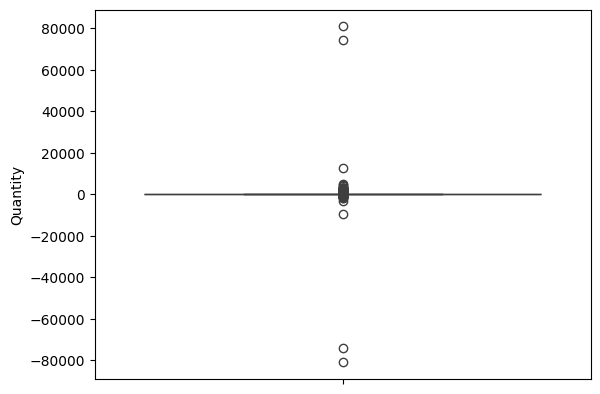

In [6]:
# Use seaborn's 'boxplot()' method
# Visualize the distribution of the 'Quantity' variable in the 'transacciones' DataFrame
sns.boxplot(y=transacciones['Quantity'])
plt.show()

In [7]:
# Calculate the first quartile (Q1) of the 'Quantity' variable in the 'transacciones' DataFrame
# Use the 'quantile()' method with the '0.25' parameter
Q1 = transacciones['Quantity'].quantile(0.25)

# Calculate the third quartile (Q3) of the 'Quantity' variable in the 'transacciones' DataFrame
# Use the 'quantile()' method with the '0.75' parameter
Q3 = transacciones['Quantity'].quantile(0.75)

# Calculate the interquartile range (IQR) of the 'Quantity' variable
# by subtracting the third quartile (Q3) minus the first quartile (Q1)
IQR = Q3 - Q1
IQR

np.float64(9.0)

In [8]:
# Define the lower bound using the formula Q1 - 1.5 * IQR
# Q1 is the first quartile, IQR is the interquartile range, and 1.5 is a scale factor
limite_inferior = Q1 - 1.5 * IQR

# Define the upper bound using the formula Q3 + 1.5 * IQR
# Q3 is the third quartile, IQR is the interquartile range, and 1.5 is a scale factor
limite_superior = Q3 + 1.5 * IQR

# Filter the outliers of the 'Quantity' variable in the 'transacciones' DataFrame
# Outliers are observations below the lower bound or above the upper bound
# We use the logical operator '|' to indicate 'or' in the condition
outliers = (transacciones['Quantity'] < limite_inferior) | (transacciones['Quantity'] > limite_superior)

# Remove the outliers from the 'Quantity' variable in the 'transacciones' DataFrame
# We use the '~' operator to negate the condition and keep the non-outlier values
transacciones = transacciones[~outliers]

<Axes: ylabel='Quantity'>

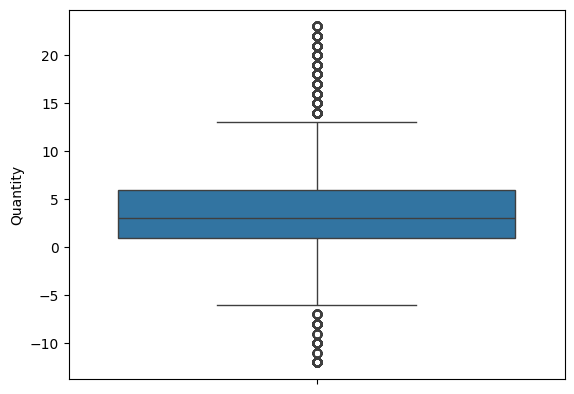

In [9]:
# Check the outliers in the 'Quantity' column again
# Use seaborn's 'boxplot()' method with the 'Quantity' variable
sns.boxplot(y=transacciones['Quantity'])

<Axes: ylabel='Quantity'>

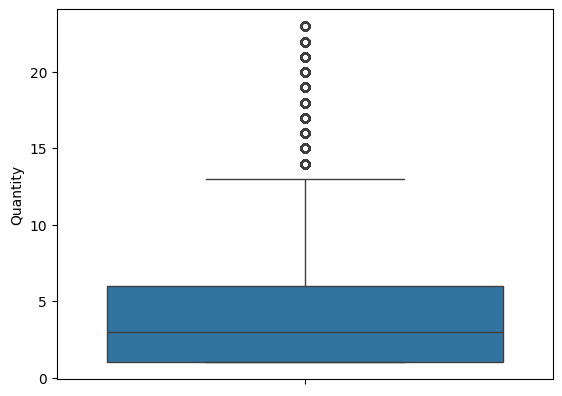

In [10]:
# Remove negative values from the 'Quantity' column in the 'transacciones' DataFrame
# Use the '>' operator to select values greater than zero (0) in the 'Quantity' column
transacciones = transacciones[transacciones['Quantity'] > 0]

# Check the outliers in the 'Quantity' column again
# Use seaborn's 'boxplot()' method with the 'Quantity' variable on the y-axis
sns.boxplot(y=transacciones['Quantity'])

### **Phase III:** Best-Selling Products and Highest Revenue-Generating Products

We create a new column for revenue per sale

In [11]:
# Use the '*' operator to multiply the 'Price' and 'Quantity' columns in the 'transacciones' DataFrame
# Assign the multiplication result to the 'Revenue' column in the 'transacciones' DataFrame
transacciones['Revenue'] = transacciones['Price'] * transacciones['Quantity']

# Display the first 5 rows of the 'transacciones' DataFrame with the 'head()' method
transacciones.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64
6,581475,12/9/2019,22118,Joy Wooden Block Letters,11.53,18,13069.0,United Kingdom,207.54


Let's check the 10 best-selling products

In [12]:
# Group the 'transacciones' DataFrame by the 'ProductName' column
# Use the 'groupby()' method and pass the 'ProductName' column as an argument
productos_agrupados = transacciones.groupby('ProductName')

# Sum the 'Quantity' column for each group
# Use the 'sum()' method to sum the 'Quantity' column of each group
suma_cantidades_por_producto = productos_agrupados['Quantity'].sum()

# Sort the results in descending order
# Use the 'sort_values()' method with the 'ascending=False' argument
# Store the result in the 'productos_mas_vendidos' variable
productos_mas_vendidos = suma_cantidades_por_producto.sort_values(ascending=False)

# Display the 10 best-selling products with the 'head()' method
productos_mas_vendidos.head(10)

ProductName
Jumbo Bag Red Retrospot               14050
Assorted Colour Bird Ornament         11062
Cream Hanging Heart T-Light Holder    10960
Lunch Bag Red Retrospot               10541
Jumbo Bag Vintage Doily                9306
Lunch Bag Vintage Doily                8405
Regency Cakestand 3 Tier               8328
Lunch Bag Suki Design                  8268
Lunch Bag Black Skull                  8218
Lunch Bag Cars Blue                    7928
Name: Quantity, dtype: int64

Let's visualize the 10 best-selling products

C:\Users\jgram\AppData\Local\Temp\ipykernel_43380\3992089701.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_mas_vendidos.head(10), y=productos_mas_vendidos.head(10).index, palette='viridis')


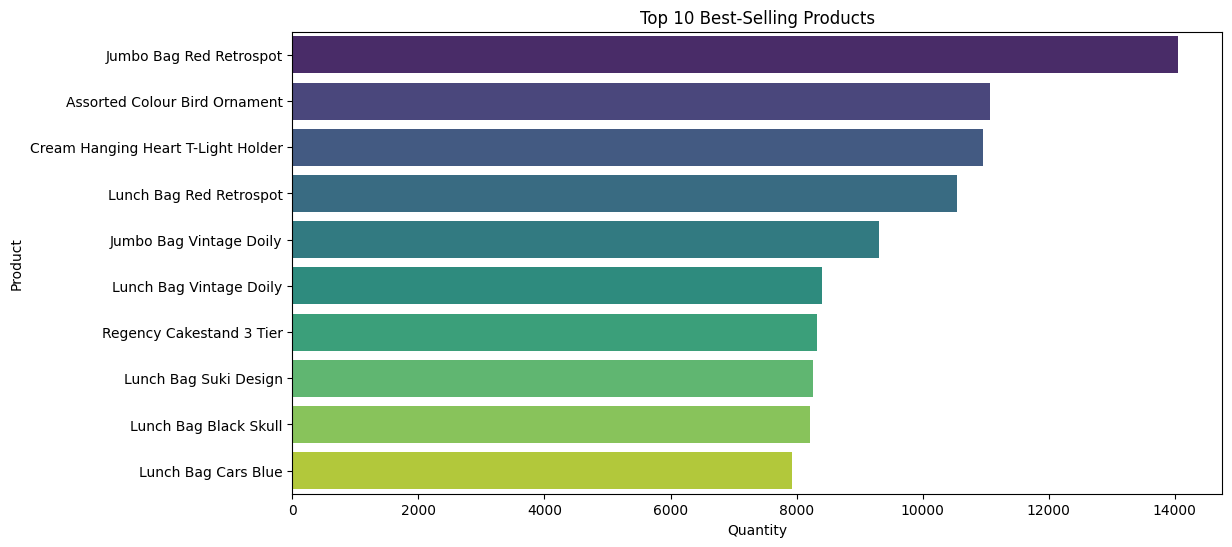

In [13]:
# Create a figure with matplotlib.pyplot's 'figure()' method
# Define the figure size with the 'figsize' parameter and dimensions (12, 6)
plt.figure(figsize=(12, 6))

# Use seaborn's 'barplot()' method to show only the 10 best-selling products
# Define the x-axis with the 'Quantity' values of 'productos_mas_vendidos'
# Define the y-axis with the index values of 'productos_mas_vendidos'
# Define the color palette with the 'palette' parameter and the value 'viridis'
sns.barplot(x=productos_mas_vendidos.head(10), y=productos_mas_vendidos.head(10).index, palette='viridis')

# Define the chart title with matplotlib.pyplot's 'title()' method
# Set the title to 'Top 10 Best-Selling Products'
plt.title('Top 10 Best-Selling Products')

# Define the x-axis label with matplotlib.pyplot's 'xlabel()' method
# Set the x-axis label to 'Quantity'
plt.xlabel('Quantity')

# Define the y-axis label with matplotlib.pyplot's 'ylabel()' method
# Set the y-axis label to 'Product'
plt.ylabel('Product')

# Display the chart with matplotlib.pyplot's 'show()' method
plt.show()

Let's check the 10 highest revenue-generating products

In [14]:
# Group the 'transacciones' DataFrame by the 'ProductName' column with the 'groupby()' method
productos_agrupados = transacciones.groupby('ProductName')

# Sum the revenue for each product using the 'sum()' method
suma_ingresos_por_producto = productos_agrupados['Revenue'].sum()

# Sort the results in descending order
# Use the 'sort_values()' method with the 'ascending=False' argument
# Store the result in the 'productos_mas_ingresos' variable
productos_mas_ingresos = suma_ingresos_por_producto.sort_values(ascending=False)

# Display the 10 highest revenue-generating products with the 'head()' method
productos_mas_ingresos.head(10)

ProductName
Regency Cakestand 3 Tier              188831.32
Cream Hanging Heart T-Light Holder    143410.29
Assorted Colour Bird Ornament         129096.00
Party Bunting                         122645.19
Jumbo Bag Red Retrospot                88625.81
Jam Making Set Printed                 88106.25
Jumbo Shopper Vintage Red Paisley      87483.07
Jumbo Storage Bag Suki                 87134.08
Popcorn Holder                         85207.51
Natural Slate Heart Chalkboard         81275.77
Name: Revenue, dtype: float64

Let's visualize the highest revenue-generating products

C:\Users\jgram\AppData\Local\Temp\ipykernel_43380\3972531928.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_mas_ingresos.head(10), y=productos_mas_ingresos.head(10).index, palette='viridis')


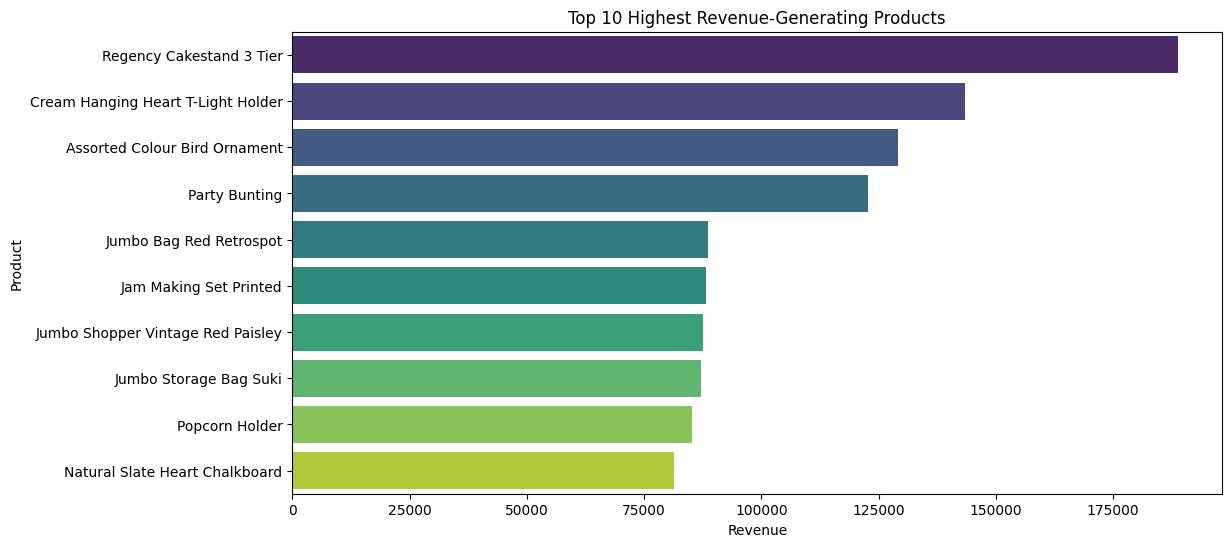

In [15]:
# Create a figure with matplotlib.pyplot's 'figure()' method
# Define the figure size with the 'figsize' parameter and dimensions (12, 6)
plt.figure(figsize=(12, 6))

# Use seaborn's 'barplot()' method 
# Visualize only the 10 highest revenue-generating products 
# Define the x-axis with the 'Revenue' values corresponding to 'productos_mas_ingresos'
# Define the y-axis with the index values of 'productos_mas_ingresos' 
sns.barplot(x=productos_mas_ingresos.head(10), y=productos_mas_ingresos.head(10).index, palette='viridis')

# Define the chart title with matplotlib.pyplot's 'title()' method
# Set the title to 'Top 10 Highest Revenue-Generating Products'
plt.title('Top 10 Highest Revenue-Generating Products')

# Define the x-axis label with matplotlib.pyplot's 'xlabel()' method
# Set the x-axis label to 'Revenue'
plt.xlabel('Revenue')

# Define the y-axis label with matplotlib.pyplot's 'ylabel()' method
# Set the y-axis label to 'Product'
plt.ylabel('Product')

# Display the chart with matplotlib.pyplot's 'show()' method
plt.show()

Let's visualize the distribution of revenue by month

C:\Users\jgram\AppData\Local\Temp\ipykernel_43380\1917468886.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_mes.index, y=ventas_por_mes.values, palette='viridis')


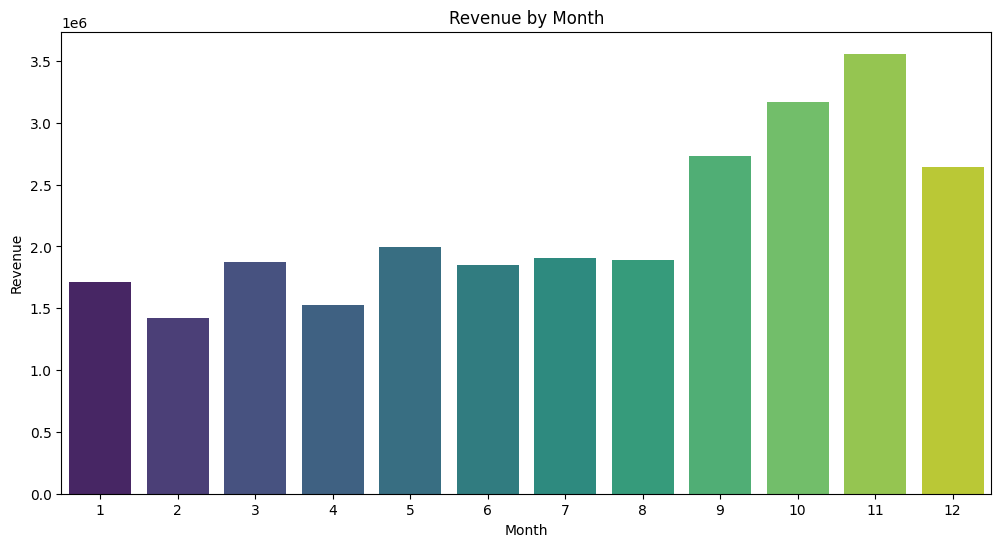

In [16]:
# Convert the 'Date' column in the 'transacciones' DataFrame to date format with the 'to_datetime()' method
# Use the format '%m/%d/%Y' to indicate month, day, and year
# Store the result in the 'Date' column of the 'transacciones' DataFrame
transacciones['Date'] = pd.to_datetime(transacciones['Date'], format  = '%m/%d/%Y')

# Create a new 'Month' column in the 'transacciones' DataFrame with the month of each transaction
# Use the 'dt.month' method to get the month from the 'Date' column
transacciones['Month'] = transacciones['Date'].dt.month

# Group the 'transacciones' DataFrame by the 'Month' column using the 'groupby()' method
# Sum the revenue per month using the 'sum()' method
# Store the results in the 'ventas_por_mes' variable
ventas_por_mes = transacciones.groupby('Month')['Revenue'].sum()

# Create a figure with matplotlib.pyplot's 'figure()' method
# Define the figure size with the 'figsize' parameter and dimensions (12, 6)
plt.figure(figsize=(12, 6))

# Use seaborn's 'barplot()' method to display the data as bars
# Define the x-axis with the index values of 'ventas_por_mes'
# Define the y-axis with the values of 'ventas_por_mes'
# Define the color palette with the 'palette' parameter and the value 'viridis'
sns.barplot(x=ventas_por_mes.index, y=ventas_por_mes.values, palette='viridis')

# Define the chart title with matplotlib.pyplot's 'title()' method
# Set the title to 'Revenue by Month'
plt.title('Revenue by Month')

# Define the x-axis label with matplotlib.pyplot's 'xlabel()' method
# Set the x-axis label to 'Month'
plt.xlabel('Month')

# Define the y-axis label with matplotlib.pyplot's 'ylabel()' method
# Set the y-axis label to 'Revenue'
plt.ylabel('Revenue')

# Display the chart with matplotlib.pyplot's 'show()' method
plt.show()

Let's visualize the distribution of sales by day of the week with a bar chart

C:\Users\jgram\AppData\Local\Temp\ipykernel_43380\274202529.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')


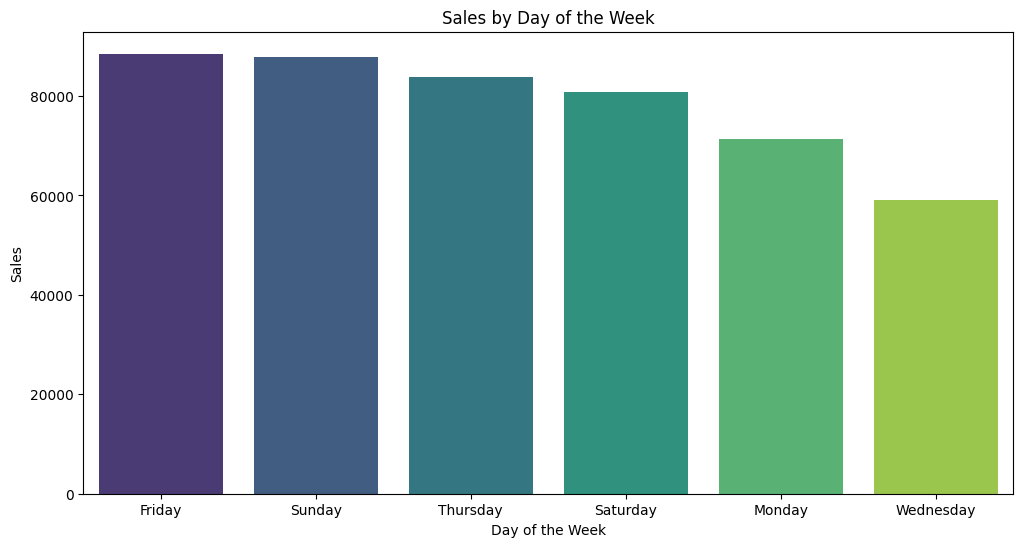

In [17]:
# Create a new 'DayOfWeek' column in the 'transacciones' DataFrame with the day of the week of each transaction
# Use the 'dt.day_name()' method to get the day name from the 'Date' column
transacciones['DayOfWeek'] = transacciones['Date'].dt.day_name()

# Count the number of sales per day of the week with the 'value_counts()' method on the 'DayOfWeek' column
# Store the results in the 'ventas_por_dia_semana' variable
ventas_por_dia_semana = transacciones['DayOfWeek'].value_counts()

# Create a figure with matplotlib.pyplot's 'figure()' method
# Define the figure size with the 'figsize' parameter and dimensions (12, 6)
plt.figure(figsize=(12, 6))

# Use seaborn's 'barplot()' method to display the data as bars
# Define the x-axis with the index values of 'ventas_por_dia_semana'
# Define the y-axis with the values of 'ventas_por_dia_semana'
# Define the color palette with the 'palette' parameter and the value 'viridis'
sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')

# Define the chart title with matplotlib.pyplot's 'title()' method
# Set the title to 'Sales by Day of the Week'
plt.title('Sales by Day of the Week')

# Define the x-axis label with matplotlib.pyplot's 'xlabel()' method
# Set the x-axis label to 'Day of the Week'
plt.xlabel('Day of the Week')

# Define the y-axis label with matplotlib.pyplot's 'ylabel()' method
# Set the y-axis label to 'Sales'
plt.ylabel('Sales')

# Display the chart with matplotlib.pyplot's 'show()' method
plt.show()